<a href="https://colab.research.google.com/github/vardaan65/Music-recommendation-based-on-emotion/blob/main/Facial_Emotion_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms
from PIL import Image

import cv2

import time

In [89]:
#Configuration

DATA_DIR = "./data"
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.002
VAL_SPLIT = 0.2
MODEL_PATH = "./model.pth"

In [90]:
device = torch.device("cuda")
print(device)

cuda


In [91]:
class CNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(), nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(4096,128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128,num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [92]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [93]:
import zipfile
import os
zip_path = 'archive.zip'
# Use DATA_DIR for extraction, defined in a previous cell
extraction_path = DATA_DIR

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

Exception ignored in: <function _ConnectionBase.__del__ at 0x7ccc345319e0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


In [94]:
train_data_dir = os.path.join(DATA_DIR, 'train')
full_dataset = datasets.ImageFolder(train_data_dir, transform=train_transform)
len(full_dataset)

28709

In [95]:
class_names = full_dataset.classes
num_class = len(class_names)
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [96]:
val_count = int(len(full_dataset)*VAL_SPLIT)
train_count = len(full_dataset) - val_count

train, val = random_split(full_dataset, [train_count, val_count])

In [97]:
train_count, val_count

(22968, 5741)

In [98]:
val.dataset.transform = val_transform

In [99]:
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, pin_memory=True)
val_loader = DataLoader(val, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [100]:
model = CNN(num_classes=num_class).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [101]:
def train():
  best_acc = 0.0

  # Initialize lists to store metrics per epoch
  train_losses = []
  train_accuracies = []
  val_losses = []
  val_accuracies = []

  all_preds_last_epoch = []
  all_labels_last_epoch = []

  for epoch in range(1, EPOCHS + 1):
    model.train()
    avg_loss = 0.0
    avg_correct = 0
    total = 0
    t0 = time.time()
    for images,labels in train_loader:
      images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      avg_loss += loss.item()*images.size(0)
      preds = outputs.argmax(dim=1)
      avg_correct += (preds == labels).sum().item()
      total += images.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    current_epoch_preds = []
    current_epoch_labels = []

    with torch.no_grad():
      for images,labels in val_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()*images.size(0)
        preds = outputs.argmax(dim=1)
        val_correct += (preds == labels).sum().item()
        val_total += images.size(0)

        current_epoch_preds.extend(preds.cpu().numpy())
        current_epoch_labels.extend(labels.cpu().numpy())

    avg_loss /= total
    avg_acc = avg_correct/total
    val_loss /= val_total
    val_acc = val_correct/val_total
    t1 = time.time()
    elapsed = t1-t0
    print(f"EPOCH {epoch}/{EPOCHS}  train_loss={avg_loss:.3f} train_acc={avg_acc:.3f}  val_loss={val_loss:.3f} val_acc={val_acc:.3f}  time={elapsed:.1f}s")

    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if epoch == EPOCHS: # Collect for the last epoch
        all_preds_last_epoch = current_epoch_preds
        all_labels_last_epoch = current_epoch_labels

    if val_acc>best_acc:
      best_acc = val_acc
      torch.save({
          "model_state" : model.state_dict(),
          "class_names" : class_names,
          "img_size" : IMG_SIZE
      }, MODEL_PATH)

      print(f"Saving the model with the best validation accuracy : {best_acc:.3f} to {MODEL_PATH}")

  print("Training completed")
  return train_losses, train_accuracies, val_losses, val_accuracies, all_preds_last_epoch, all_labels_last_epoch

In [102]:
def inference(image_path=None):
  checkpoint = torch.load(MODEL_PATH,map_location=device)
  model.load_state_dict(checkpoint["model_state"])
  model.to(device)
  model.eval()
  class_names = checkpoint["class_names"]

  if image_path:
    try:
      img = Image.open(image_path).convert('RGB')
      resize_img = img.resize((IMG_SIZE, IMG_SIZE))
      tensor = transforms.functional.to_tensor(resize_img)
      tensor = transforms.functional.normalize(tensor,[0.485,0.456,0.406],[0.229,0.224,0.225])
      tensor = tensor.unsqueeze(0).to(device)

      with torch.no_grad():
        out = model(tensor)
        probs = torch.nn.functional.softmax(out, dim=1)
        top_prob, prob_idx = torch.max(probs, dim=1)
        label = class_names[prob_idx.item()]
        conf = top_prob.item()

      print(f"Predicted: {label} with confidence {conf:.2f}")

    except FileNotFoundError:
      print(f"Error: Image file not found at {image_path}")
    except Exception as e:
      print(f"An error occurred during image inference: {e}")

  else:
    print("Webcam is starting... press q to quit")
    webcam = cv2.VideoCapture(0)
    if not webcam.isOpened():
      print("Webcam error")
      return

    while True:
      ret, frame = webcam.read()

      if not ret:
        break

      rbg = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
      resize_img = Image.fromarray(rbg).resize((IMG_SIZE, IMG_SIZE))
      tensor = transforms.functional.to_tensor(resize_img)
      tensor = transforms.functional.normalize(tensor,[0.485,0.456,0.406],[0.229,0.224,0.225])
      tensor = tensor.unsqueeze(0).to(device)

      with torch.no_grad():
        out = model(tensor)
        probs = torch.nn.functional.softmax(out, dim=1)
        top_prob, prob_idx = torch.max(probs, dim=1)
        label = class_names[prob_idx.item()]
        conf = top_prob.item()

      cv2.putText(frame, f"{label} {conf:.2f}", (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,0), 2)
      cv2.imshow("Emotion Detector (q to quit)", frame)

      if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    webcam.release()
    cv2.destroyAllWindows()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


EPOCH 1/100  train_loss=0.902 train_acc=0.649  val_loss=1.365 val_acc=0.548  time=20.9s
Saving the model with the best validation accuracy : 0.548 to ./model.pth
EPOCH 2/100  train_loss=0.885 train_acc=0.657  val_loss=1.370 val_acc=0.541  time=20.1s
EPOCH 3/100  train_loss=0.870 train_acc=0.666  val_loss=1.370 val_acc=0.543  time=21.0s
EPOCH 4/100  train_loss=0.867 train_acc=0.662  val_loss=1.423 val_acc=0.547  time=19.8s
EPOCH 5/100  train_loss=0.849 train_acc=0.671  val_loss=1.389 val_acc=0.544  time=20.5s
EPOCH 6/100  train_loss=0.839 train_acc=0.675  val_loss=1.427 val_acc=0.536  time=23.0s
EPOCH 7/100  train_loss=0.831 train_acc=0.675  val_loss=1.419 val_acc=0.539  time=25.2s
EPOCH 8/100  train_loss=0.819 train_acc=0.679  val_loss=1.432 val_acc=0.535  time=19.7s
EPOCH 9/100  train_loss=0.810 train_acc=0.684  val_loss=1.472 val_acc=0.531  time=21.0s
EPOCH 10/100  train_loss=0.805 train_acc=0.684  val_loss=1.460 val_acc=0.536  time=19.4s
EPOCH 11/100  train_loss=0.791 train_acc=0.69

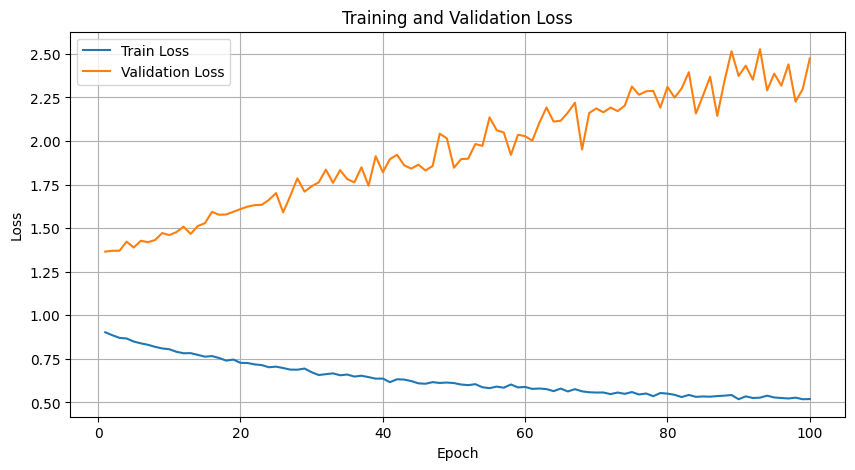

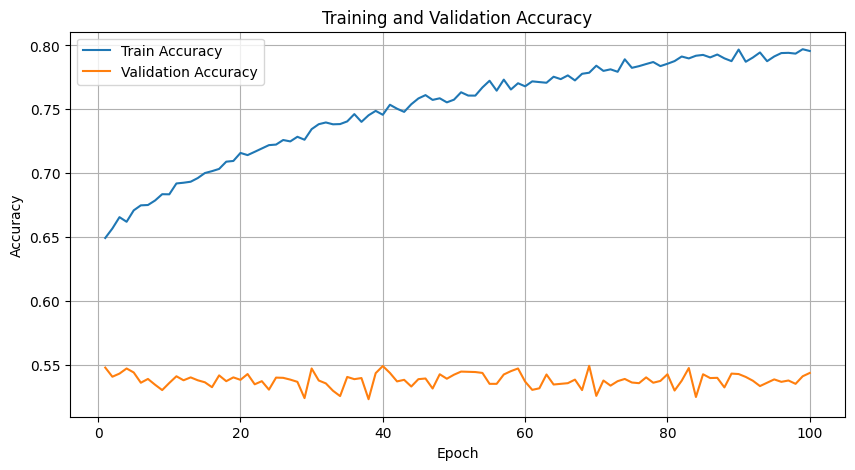

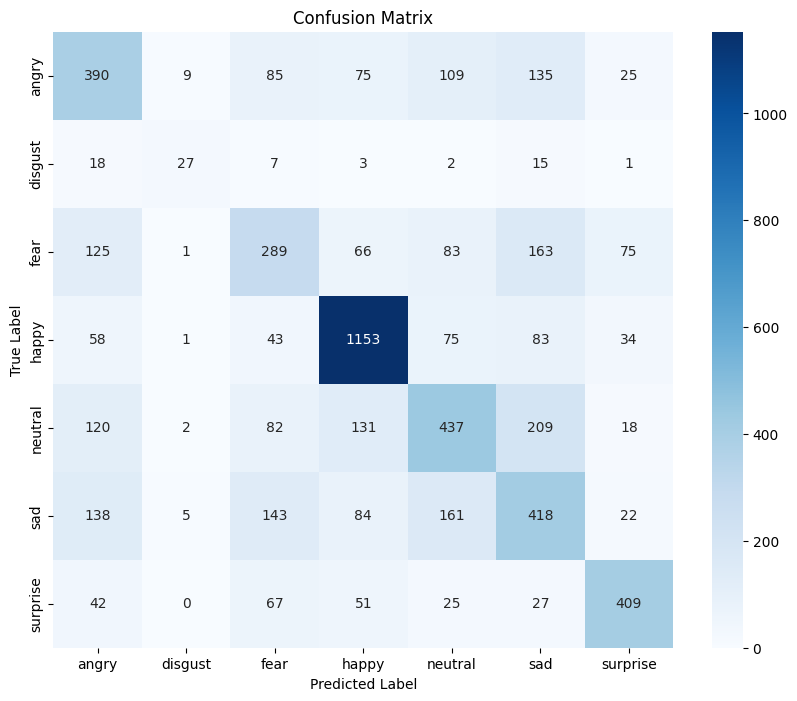

Overall Validation Accuracy: 0.544


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
train_loss, train_acc, val_loss, val_acc, all_preds, all_labels = train()

# Plotting training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_loss, label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_acc, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Overall Accuracy
overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Validation Accuracy: {overall_accuracy:.3f}")

📁 Upload a face image...


Saving sad2.jpg to sad2 (1).jpg


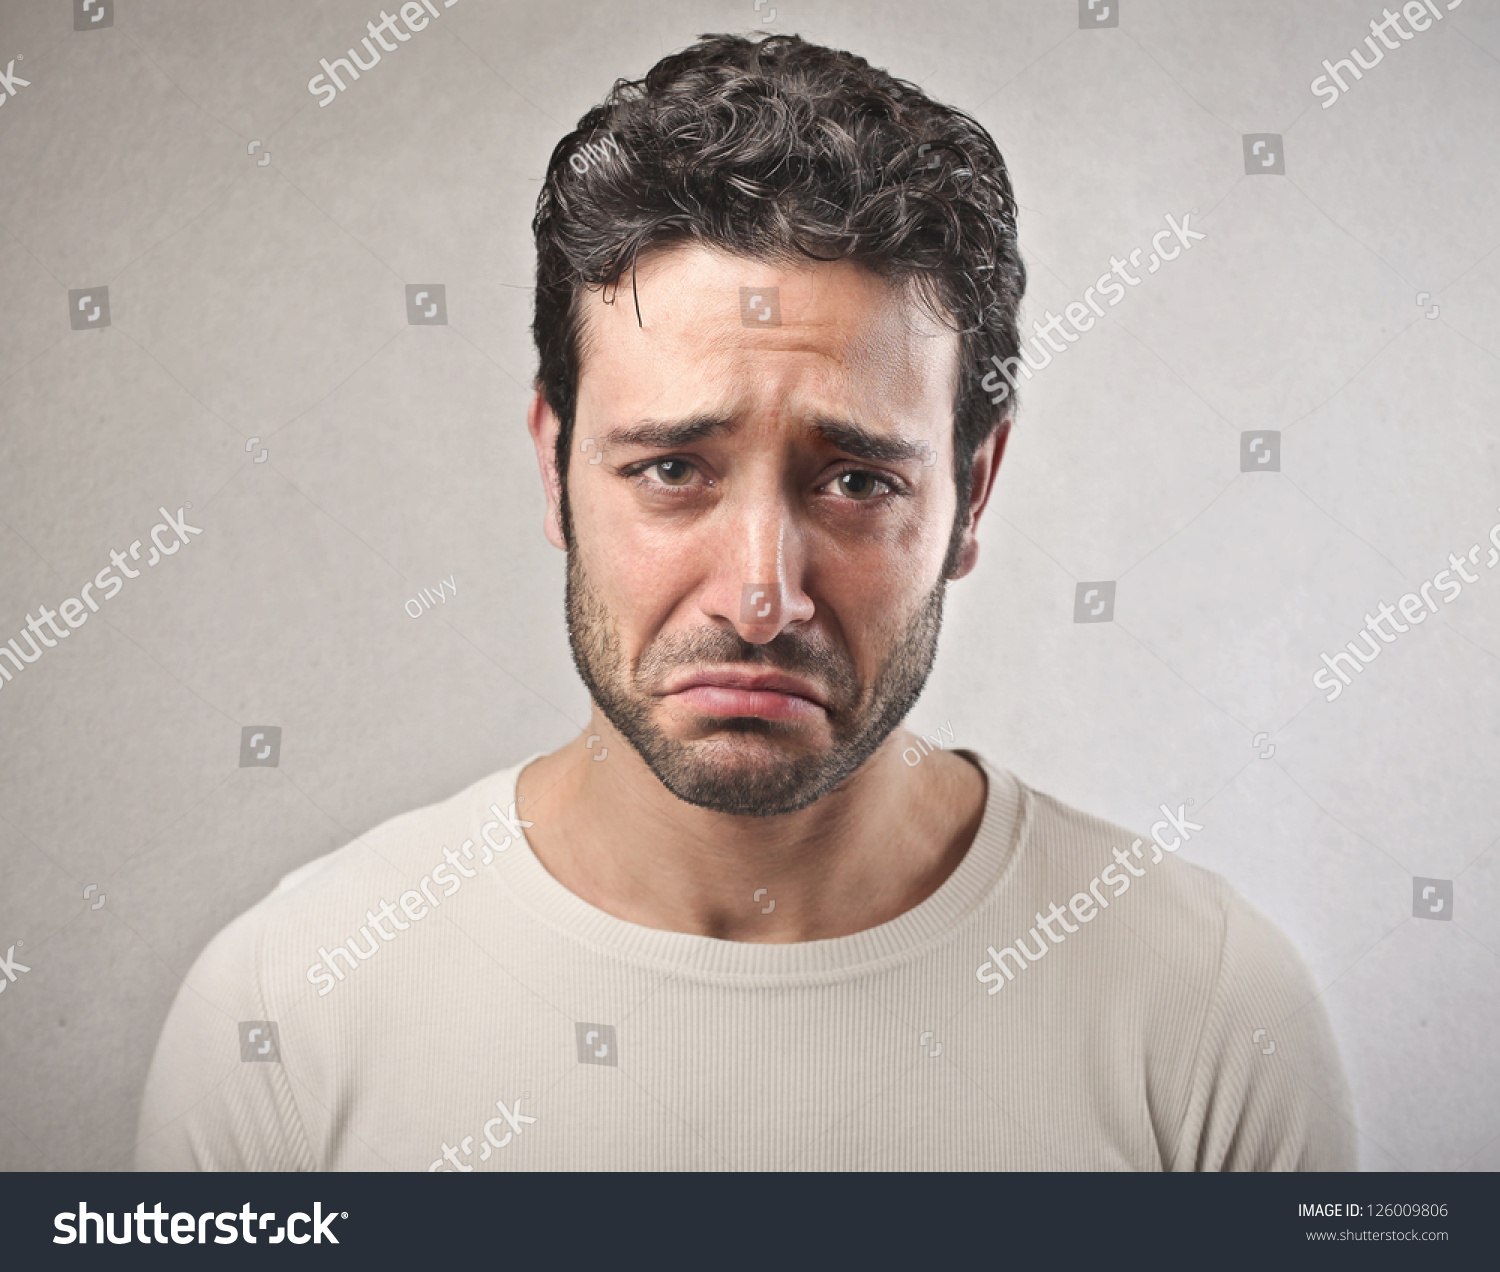

#,Song,Play
1,Adele - Someone Like You,▶ YouTube
2,Lewis Capaldi - Someone You Loved,▶ YouTube
3,Billie Eilish - When the Party's Over,▶ YouTube
4,Lo-fi Chill Beats,▶ YouTube
5,James Arthur - Say You Won't Let Go,▶ YouTube


In [117]:
from google.colab import files
from IPython.display import display, HTML
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import io

# ── Song playlist per emotion (title + YouTube URL) ───────────────────────────
MUSIC_MAP = {
    "happy": [
        ("Pharrell Williams - Happy",         "https://www.youtube.com/watch?v=ZbZSe6N_BXs"),
        ("Katy Perry - Roar",                 "https://www.youtube.com/watch?v=CevxZvSJLk8"),
        ("Justin Timberlake - Can't Stop the Feeling", "https://www.youtube.com/watch?v=ru0K8uYEZWw"),
        ("Lizzo - Good as Hell",              "https://www.youtube.com/watch?v=SmbmeOgWsqE"),
        ("Bruno Mars - Uptown Funk",          "https://www.youtube.com/watch?v=OPf0YbXqDm0"),
    ],
    "sad": [
        ("Adele - Someone Like You",          "https://www.youtube.com/watch?v=hLQl3WQQoQ0"),
        ("Lewis Capaldi - Someone You Loved", "https://www.youtube.com/watch?v=zABniqxAA3E"),
        ("Billie Eilish - When the Party's Over", "https://www.youtube.com/watch?v=pbMwTqkKSps"),
        ("Lo-fi Chill Beats",                 "https://www.youtube.com/watch?v=5qap5aO4i9A"),
        ("James Arthur - Say You Won't Let Go","https://www.youtube.com/watch?v=0yW7w8F2TVA"),
    ],
    "angry": [
        ("Linkin Park - Numb",                "https://www.youtube.com/watch?v=kXYiU_JCYtU"),
        ("Eminem - Lose Yourself",            "https://www.youtube.com/watch?v=_Yhyp-_hX2s"),
        ("System of a Down - Chop Suey",      "https://www.youtube.com/watch?v=CSvFpBOe8eY"),
        ("Rage Against the Machine - Killing in the Name", "https://www.youtube.com/watch?v=bWXazVhlyxQ"),
        ("Slipknot - Wait and Bleed",         "https://www.youtube.com/watch?v=eqn-hgPyMsQ"),
    ],
    "fear": [
        ("Weightless - Marconi Union",        "https://www.youtube.com/watch?v=UfcAVejslrU"),
        ("Peaceful Ambient Mix",              "https://www.youtube.com/watch?v=lFcSrYw-ARY"),
        ("Enya - Only Time",                  "https://www.youtube.com/watch?v=82bIRBgGnB4"),
        ("Relaxing Nature Sounds",            "https://www.youtube.com/watch?v=eKFTSSKCzWA"),
        ("Hans Zimmer - Time",                "https://www.youtube.com/watch?v=RxabLA7UQ9k"),
    ],
    "surprise": [
        ("Daft Punk - Get Lucky",             "https://www.youtube.com/watch?v=5NV6Rdv1a3I"),
        ("The Weeknd - Blinding Lights",      "https://www.youtube.com/watch?v=4NRXx6U8ABQ"),
        ("David Bowie - Let's Dance",         "https://www.youtube.com/watch?v=N4d7Wp9kKjA"),
        ("Dua Lipa - Levitating",             "https://www.youtube.com/watch?v=TUVcZfQe-Kw"),
        ("Energetic Electronic Mix",          "https://www.youtube.com/watch?v=1y6smkh6c-0"),
    ],
    "disgust": [
        ("Arctic Monkeys - R U Mine?",        "https://www.youtube.com/watch?v=sEnougS6Nf8"),
        ("Tame Impala - The Less I Know the Better", "https://www.youtube.com/watch?v=2SUwOgmvzK4"),
        ("Radiohead - Creep",                 "https://www.youtube.com/watch?v=XFkzRNyygfk"),
        ("Alt-J - Something Good",            "https://www.youtube.com/watch?v=sLmHTNMRPak"),
        ("Indie Chill Playlist",              "https://www.youtube.com/watch?v=ktvTqknDobU"),
    ],
    "neutral": [
        ("Miles Davis - So What",             "https://www.youtube.com/watch?v=ylXk1LBvIqU"),
        ("Beethoven - Moonlight Sonata",      "https://www.youtube.com/watch?v=4Tr0otuiQuU"),
        ("Lo-fi Study Beats",                 "https://www.youtube.com/watch?v=5qap5aO4i9A"),
        ("Norah Jones - Come Away With Me",   "https://www.youtube.com/watch?v=AL9TPKXB-HY"),
        ("Classical Focus Music",             "https://www.youtube.com/watch?v=4oStw0r33so"),
    ],
}

# ── Emotion display colours ───────────────────────────────────────────────────
EMOTION_COLORS = {
    "happy":    "#F59E0B",
    "sad":      "#3B82F6",
    "angry":    "#EF4444",
    "fear":     "#8B5CF6",
    "surprise": "#10B981",
    "disgust":  "#6B7280",
    "neutral":  "#64748B",
}

# ── Music recommendation display ──────────────────────────────────────────────
def show_music_recommendations(emotion, conf):
    songs  = MUSIC_MAP.get(emotion.lower(), [])
    color  = EMOTION_COLORS.get(emotion.lower(), "#1DB954")

    html = f"""
    <div style="font-family: Arial, sans-serif; padding: 16px;
                border-left: 5px solid {color}; background: #f9f9f9;
                border-radius: 8px; margin-top: 12px;">

        <h2 style="color:{color}; margin:0 0 4px 0;">
            🎭 Detected Emotion: {emotion.upper()}
        </h2>
        <p style="color:#555; margin:0 0 16px 0;">
            Confidence: <b>{conf:.0%}</b>
        </p>

        <h3 style="color:#333; margin:0 0 10px 0;">🎵 Recommended Songs</h3>
        <table style="border-collapse:collapse; width:100%;">
            <tr style="background:{color}; color:white;">
                <th style="padding:8px 12px; text-align:left;">#</th>
                <th style="padding:8px 12px; text-align:left;">Song</th>
                <th style="padding:8px 12px; text-align:left;">Play</th>
            </tr>
    """

    for i, (title, url) in enumerate(songs, 1):
        row_bg = "#ffffff" if i % 2 == 0 else "#f3f4f6"
        html += f"""
            <tr style="background:{row_bg};">
                <td style="padding:8px 12px; color:#888;">{i}</td>
                <td style="padding:8px 12px; color:#333;">{title}</td>
                <td style="padding:8px 12px;">
                    <a href="{url}" target="_blank"
                       style="background:#FF0000; color:white; padding:5px 12px;
                              border-radius:4px; text-decoration:none;
                              font-size:13px; font-weight:bold;">
                        ▶ YouTube
                    </a>
                </td>
            </tr>
        """

    html += "</table></div>"
    display(HTML(html))


# ── Inference function ────────────────────────────────────────────────────────
def inference(image_path=None):
    checkpoint  = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()
    class_names = checkpoint["class_names"]

    if image_path:
        try:
            img        = Image.open(image_path).convert("RGB")
            resize_img = img.resize((IMG_SIZE, IMG_SIZE))
            tensor     = transforms.functional.to_tensor(resize_img)
            tensor     = transforms.functional.normalize(
                             tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            tensor     = tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                out           = model(tensor)
                probs         = torch.nn.functional.softmax(out, dim=1)
                top_prob, idx = torch.max(probs, dim=1)
                label         = class_names[idx.item()]
                conf          = top_prob.item()

            # Show uploaded image
            display(img)

            # Show music recommendations
            show_music_recommendations(label, conf)

        except FileNotFoundError:
            print(f"Error: Image file not found at {image_path}")
        except Exception as e:
            print(f"An error occurred: {e}")

    else:
        # Colab image upload (no webcam)
        print("📁 Upload a face image...")
        uploaded = files.upload()

        for filename, data in uploaded.items():
            img        = Image.open(io.BytesIO(data)).convert("RGB")
            resize_img = img.resize((IMG_SIZE, IMG_SIZE))
            tensor     = transforms.functional.to_tensor(resize_img)
            tensor     = transforms.functional.normalize(
                             tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            tensor     = tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                out           = model(tensor)
                probs         = torch.nn.functional.softmax(out, dim=1)
                top_prob, idx = torch.max(probs, dim=1)
                label         = class_names[idx.item()]
                conf          = top_prob.item()

            # Show uploaded image
            display(img)

            # Show music recommendations
            show_music_recommendations(label, conf)


# ── Run ───────────────────────────────────────────────────────────────────────
inference()   # uploads image via Colab file picker
# inference("path/to/image.jpg")  # or pass a path directly